## 2.2 编程题

In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# 设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 超参数
batch_size = 256
learning_rate = 0.1
num_epochs = 10
hidden_size = 256
input_size = 28 * 28
num_classes = 10

# 加载 Fashion-MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 初始化参数（正态分布）
def init_parameters():
    W1 = torch.normal(0, 0.01, size=(hidden_size, input_size), device=device, requires_grad=False)
    b1 = torch.zeros(hidden_size, device=device, requires_grad=False)
    W2 = torch.normal(0, 0.01, size=(num_classes, hidden_size), device=device, requires_grad=False)
    b2 = torch.zeros(num_classes, device=device, requires_grad=False)
    return W1, b1, W2, b2

W1, b1, W2, b2 = init_parameters()

# ReLU 激活函数
def relu(x):
    return torch.maximum(x, torch.tensor(0.0, device=x.device))

# Softmax 交叉熵损失（返回损失和概率）
def softmax_cross_entropy(logits, labels):
    logits_max = logits.max(dim=1, keepdim=True)[0]
    exp_logits = torch.exp(logits - logits_max)
    probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)
    batch_size = logits.shape[0]
    loss = -torch.log(probs[range(batch_size), labels] + 1e-8).mean()
    return loss, probs

# 前向传播（返回 logits 和隐藏层输出）
def forward(X, W1, b1, W2, b2):
    h = relu(X @ W1.T + b1)   # 隐藏层
    o = h @ W2.T + b2         # 输出 logits
    return o, h

# 训练一个 epoch（手动反向传播）
def train_epoch(train_loader, W1, b1, W2, b2, lr):
    total_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        batch_size = X.shape[0]
        
        # 前向
        logits, h = forward(X, W1, b1, W2, b2)
        loss, probs = softmax_cross_entropy(logits, y)
        total_loss += loss.item()
        
        # 反向传播
        # 输出层梯度
        one_hot = torch.zeros_like(probs)
        one_hot[range(batch_size), y] = 1
        d_logits = (probs - one_hot) / batch_size   # 平均梯度
        
        dW2 = d_logits.T @ h
        db2 = d_logits.sum(dim=0)
        
        # 隐藏层梯度
        d_h = d_logits @ W2
        d_h[h <= 0] = 0      # ReLU 导数
        dW1 = d_h.T @ X
        db1 = d_h.sum(dim=0)
        
        # 更新参数（无梯度记录）
        with torch.no_grad():
            W1 -= lr * dW1
            b1 -= lr * db1
            W2 -= lr * dW2
            b2 -= lr * db2
    return total_loss / len(train_loader)

# 评估测试准确率
def evaluate(test_loader, W1, b1, W2, b2):
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            logits, _ = forward(X, W1, b1, W2, b2)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

# 训练循环
print("开始训练...")
for epoch in range(num_epochs):
    loss = train_epoch(train_loader, W1, b1, W2, b2, learning_rate)
    acc = evaluate(test_loader, W1, b1, W2, b2)
    print(f"Epoch {epoch+1:2d}, Loss: {loss:.4f}, Test Acc: {acc:.4f}")

Using device: cpu


100%|██████████| 26.4M/26.4M [00:02<00:00, 9.21MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 161kB/s]
100%|██████████| 4.42M/4.42M [00:03<00:00, 1.41MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]


开始训练...
Epoch  1, Loss: 1.0500, Test Acc: 0.7195
Epoch  2, Loss: 0.6018, Test Acc: 0.7727
Epoch  3, Loss: 0.5211, Test Acc: 0.7796
Epoch  4, Loss: 0.4813, Test Acc: 0.8247
Epoch  5, Loss: 0.4553, Test Acc: 0.8372
Epoch  6, Loss: 0.4289, Test Acc: 0.8391
Epoch  7, Loss: 0.4164, Test Acc: 0.8418
Epoch  8, Loss: 0.4017, Test Acc: 0.8382
Epoch  9, Loss: 0.3885, Test Acc: 0.8537
Epoch 10, Loss: 0.3793, Test Acc: 0.8430


## 3.2 编程题

=== 1. 无正则化 ===
Epoch  10, Loss: 1.8002, Test Acc: 0.5398
Epoch  20, Loss: 1.2600, Test Acc: 0.6311
Epoch  30, Loss: 1.0074, Test Acc: 0.6563
Epoch  40, Loss: 0.8792, Test Acc: 0.6762
Epoch  50, Loss: 0.7959, Test Acc: 0.6927

=== 2. 权重衰减 (L2) ===
Epoch  10, Loss: 1.8070, Test Acc: 0.5306
Epoch  20, Loss: 1.2618, Test Acc: 0.6209
Epoch  30, Loss: 1.0123, Test Acc: 0.6531
Epoch  40, Loss: 0.8790, Test Acc: 0.6722
Epoch  50, Loss: 0.7949, Test Acc: 0.6912

=== 3. Dropout ===
Epoch  10, Loss: 1.7931, Test Acc: 0.5450
Epoch  20, Loss: 1.2736, Test Acc: 0.6243
Epoch  30, Loss: 1.0355, Test Acc: 0.6551
Epoch  40, Loss: 0.9059, Test Acc: 0.6689
Epoch  50, Loss: 0.8272, Test Acc: 0.6895


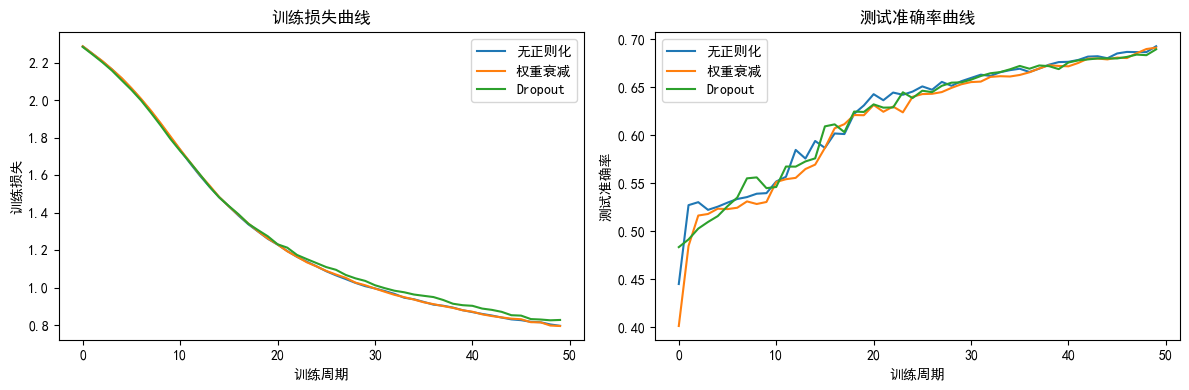

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# ========== 中文字体设置 ==========
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']  # 备选字体
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号
# ==================================

# 设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 超参数
batch_size = 64
learning_rate = 0.01
num_epochs = 50
hidden_size = 1024          # 大模型，容易过拟合
input_size = 28*28
num_classes = 10
weight_decay = 1e-4         # L2正则化系数
dropout_rate = 0.5

# 加载Fashion-MNIST，但只使用一小部分训练样本来加剧过拟合
train_dataset_full = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True,
    transform=transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True,
    transform=transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
)

# 取前1000个训练样本
train_subset = torch.utils.data.Subset(train_dataset_full, range(1000))
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 参数初始化
def init_params():
    W1 = torch.normal(0, 0.01, size=(hidden_size, input_size), device=device, requires_grad=False)
    b1 = torch.zeros(hidden_size, device=device, requires_grad=False)
    W2 = torch.normal(0, 0.01, size=(num_classes, hidden_size), device=device, requires_grad=False)
    b2 = torch.zeros(num_classes, device=device, requires_grad=False)
    return W1, b1, W2, b2

# ReLU
def relu(x):
    return torch.maximum(x, torch.tensor(0.0, device=x.device))

# Dropout层实现
def dropout_layer(x, dropout, is_training=True):
    if not is_training or dropout == 0:
        return x
    mask = (torch.rand_like(x) > dropout).float()
    return x * mask / (1.0 - dropout)

# 前向传播（带Dropout）
def forward(X, W1, b1, W2, b2, dropout=0.0, is_training=True):
    h1 = relu(X @ W1.T + b1)
    h1 = dropout_layer(h1, dropout, is_training)
    logits = h1 @ W2.T + b2
    return logits, h1

# Softmax交叉熵损失
def cross_entropy_loss(logits, labels):
    return torch.nn.functional.cross_entropy(logits, labels)

# 训练一个epoch（包含权重衰减手动实现）
def train_epoch(train_loader, W1, b1, W2, b2, lr, wd, dropout, is_training=True):
    total_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        # 前向
        logits, _ = forward(X, W1, b1, W2, b2, dropout, is_training)
        loss = cross_entropy_loss(logits, y)
        total_loss += loss.item()
        # 反向传播（自动求导）
        loss.backward()
        with torch.no_grad():
            # 权重衰减: w = w - lr * (grad + wd * w)
            W1 -= lr * (W1.grad + wd * W1)
            b1 -= lr * b1.grad
            W2 -= lr * (W2.grad + wd * W2)
            b2 -= lr * b2.grad
            # 梯度清零
            W1.grad.zero_()
            b1.grad.zero_()
            W2.grad.zero_()
            b2.grad.zero_()
    return total_loss / len(train_loader)

def evaluate(test_loader, W1, b1, W2, b2, dropout=0.0):
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            logits, _ = forward(X, W1, b1, W2, b2, dropout, is_training=False)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

# 训练函数（记录loss和acc曲线）
def train_model(W1, b1, W2, b2, lr, wd, dropout, epochs, train_loader, test_loader):
    train_losses = []
    test_accs = []
    for epoch in range(epochs):
        loss = train_epoch(train_loader, W1, b1, W2, b2, lr, wd, dropout, is_training=True)
        acc = evaluate(test_loader, W1, b1, W2, b2, dropout=0.0)
        train_losses.append(loss)
        test_accs.append(acc)
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}, Loss: {loss:.4f}, Test Acc: {acc:.4f}")
    return train_losses, test_accs

# 三种情况对比
print("=== 1. 无正则化 ===")
W1, b1, W2, b2 = init_params()
W1.requires_grad_(); b1.requires_grad_(); W2.requires_grad_(); b2.requires_grad_()
losses_no_reg, accs_no_reg = train_model(W1, b1, W2, b2, lr=0.01, wd=0.0, dropout=0.0, epochs=50,
                                          train_loader=train_loader, test_loader=test_loader)

print("\n=== 2. 权重衰减 (L2) ===")
W1, b1, W2, b2 = init_params()
W1.requires_grad_(); b1.requires_grad_(); W2.requires_grad_(); b2.requires_grad_()
losses_wd, accs_wd = train_model(W1, b1, W2, b2, lr=0.01, wd=1e-4, dropout=0.0, epochs=50,
                                 train_loader=train_loader, test_loader=test_loader)

print("\n=== 3. Dropout ===")
W1, b1, W2, b2 = init_params()
W1.requires_grad_(); b1.requires_grad_(); W2.requires_grad_(); b2.requires_grad_()
losses_drop, accs_drop = train_model(W1, b1, W2, b2, lr=0.01, wd=0.0, dropout=0.5, epochs=50,
                                     train_loader=train_loader, test_loader=test_loader)

# ========== 绘制中文版曲线 ==========
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(losses_no_reg, label='无正则化')
plt.plot(losses_wd, label='权重衰减')
plt.plot(losses_drop, label='Dropout')
plt.xlabel('训练周期')
plt.ylabel('训练损失')
plt.legend()
plt.title('训练损失曲线')

plt.subplot(1,2,2)
plt.plot(accs_no_reg, label='无正则化')
plt.plot(accs_wd, label='权重衰减')
plt.plot(accs_drop, label='Dropout')
plt.xlabel('训练周期')
plt.ylabel('测试准确率')
plt.legend()
plt.title('测试准确率曲线')

plt.tight_layout()
plt.show()

## 4.2 编程题

Sigmoid + 普通初始化 (std=1): 梯度范数（每层权重梯度）
第 1 层: 904.621643
第 2 层: 462.985016
第 3 层: 368.272797
第 4 层: 281.595459
第 5 层: 258.352844
第 6 层: 163.560455
第 7 层: 142.309753
第 8 层: 102.739334
第 9 层: 75.675415
第 10 层: 74.392860
第 11 层: 59.300758
第 12 层: 52.296707
第 13 层: 39.941742
第 14 层: 35.231434
第 15 层: 30.159443
第 16 层: 20.762627
第 17 层: 16.916225
第 18 层: 13.386932
第 19 层: 15.414734
第 20 层: 13.311138

ReLU + 大标准差 (std=10): 梯度范数
第 1 层: nan
第 2 层: inf
第 3 层: inf
第 4 层: inf
第 5 层: inf
第 6 层: inf
第 7 层: inf
第 8 层: inf
第 9 层: inf
第 10 层: inf
第 11 层: inf
第 12 层: inf
第 13 层: inf
第 14 层: inf
第 15 层: inf
第 16 层: inf
第 17 层: inf
第 18 层: inf
第 19 层: inf
第 20 层: nan

Xavier 初始化 + ReLU: 梯度范数
第 1 层: 0.312547
第 2 层: 0.303534
第 3 层: 0.298866
第 4 层: 0.334734
第 5 层: 0.325416
第 6 层: 0.352752
第 7 层: 0.447100
第 8 层: 0.393818
第 9 层: 0.341450
第 10 层: 0.344243
第 11 层: 0.420731
第 12 层: 0.501517
第 13 层: 0.773484
第 14 层: 1.103399
第 15 层: 1.570665
第 16 层: 2.154146
第 17 层: 2.464300
第 18 层: 4.206891
第 19 层: 5.247271
第 20 

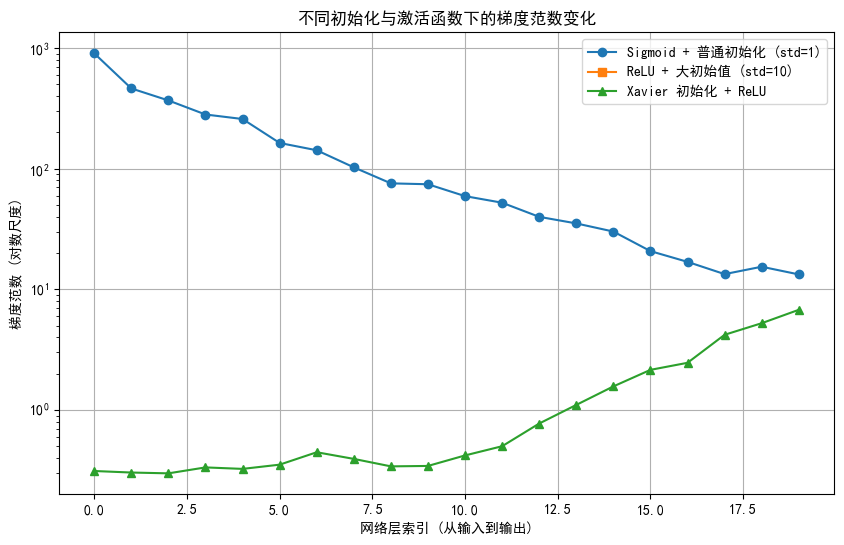

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ========== 设置中文字体 ==========
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False
# ==================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_deep_net(layers=20, width=256, activation='sigmoid', init_method='normal'):
    layers_list = []
    for i in range(layers):
        linear = nn.Linear(width, width)
        if init_method == 'normal':
            nn.init.normal_(linear.weight, mean=0, std=1)
        elif init_method == 'xavier':
            nn.init.xavier_uniform_(linear.weight)
        layers_list.append(linear)
        if activation == 'sigmoid':
            layers_list.append(nn.Sigmoid())
        elif activation == 'relu':
            layers_list.append(nn.ReLU())
        elif activation == 'leaky_relu':
            layers_list.append(nn.LeakyReLU(0.2))
    net = nn.Sequential(*layers_list)
    return net

def compute_gradient_norms(net, x):
    net.train()
    net.zero_grad()
    out = net(x)
    loss = out.sum()
    loss.backward()
    norms = []
    for name, param in net.named_parameters():
        if param.grad is not None and 'weight' in name:
            norms.append(param.grad.norm(2).item())
    return norms

# 实验1：Sigmoid + 普通初始化（std=1）
net = build_deep_net(layers=20, width=256, activation='sigmoid', init_method='normal')
x = torch.randn(1, 256, device=device)
norms_sigmoid = compute_gradient_norms(net, x)
print("Sigmoid + 普通初始化 (std=1): 梯度范数（每层权重梯度）")
for i, norm in enumerate(norms_sigmoid):
    print(f"第 {i+1} 层: {norm:.6f}")

# 实验2：ReLU + 大初始值（std=10）
net = build_deep_net(layers=20, width=256, activation='relu', init_method='normal')
for m in net.modules():
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=10)
x = torch.randn(1, 256, device=device)
norms_relu_large = None
try:
    norms_relu_large = compute_gradient_norms(net, x)
    print("\nReLU + 大标准差 (std=10): 梯度范数")
    for i, norm in enumerate(norms_relu_large):
        print(f"第 {i+1} 层: {norm:.6f}")
except Exception as e:
    print("\nReLU + std=10 导致数值溢出 (NaN):", e)

# 实验3：Xavier初始化 + ReLU
net = build_deep_net(layers=20, width=256, activation='relu', init_method='xavier')
x = torch.randn(1, 256, device=device)
norms_xavier_relu = compute_gradient_norms(net, x)
print("\nXavier 初始化 + ReLU: 梯度范数")
for i, norm in enumerate(norms_xavier_relu):
    print(f"第 {i+1} 层: {norm:.6f}")

# ========== 绘制中文可视化 ==========
plt.figure(figsize=(10,6))
plt.plot(norms_sigmoid, marker='o', label='Sigmoid + 普通初始化 (std=1)')
if norms_relu_large is not None:
    plt.plot(norms_relu_large, marker='s', label='ReLU + 大初始值 (std=10)')
plt.plot(norms_xavier_relu, marker='^', label='Xavier 初始化 + ReLU')
plt.yscale('log')
plt.xlabel('网络层索引 (从输入到输出)')
plt.ylabel('梯度范数 (对数尺度)')
plt.title('不同初始化与激活函数下的梯度范数变化')
plt.legend()
plt.grid(True)
plt.show()


## 5.2 编程题

基线模型 MSE: 0.0102
加权回归 MSE: 0.0240


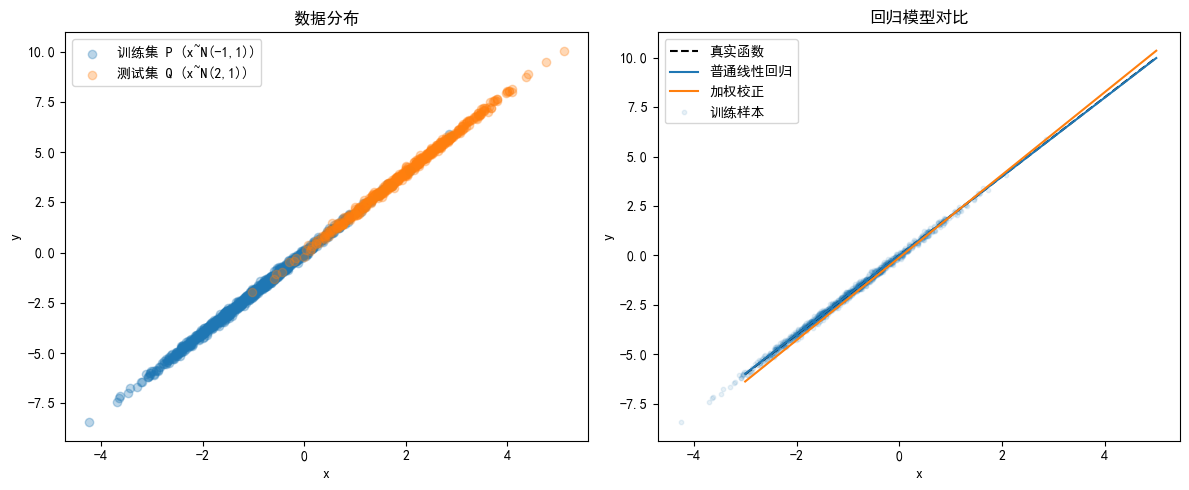

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

# ========== 设置中文字体 ==========
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False
# ==================================

# 1. 生成数据
np.random.seed(42)
n_train = 1000
n_test = 500

# 训练集 P: x ~ N(-1,1)
x_train = np.random.normal(-1, 1, n_train)
eps_train = np.random.normal(0, 0.1, n_train)
y_train = 2 * x_train + eps_train

# 测试集 Q: x ~ N(2,1)
x_test = np.random.normal(2, 1, n_test)
eps_test = np.random.normal(0, 0.1, n_test)
y_test = 2 * x_test + eps_test

# 2. 基线模型：普通线性回归
lr_baseline = LinearRegression()
lr_baseline.fit(x_train.reshape(-1,1), y_train)
y_pred_baseline = lr_baseline.predict(x_test.reshape(-1,1))
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
print(f"基线模型 MSE: {mse_baseline:.4f}")

# 3. 协变量偏移校正
# 3a. 训练逻辑回归分类器区分训练样本(0)和测试样本(1)
X_mix = np.concatenate([x_train, x_test]).reshape(-1,1)
y_mix = np.concatenate([np.zeros(n_train), np.ones(n_test)])
clf = LogisticRegression()
clf.fit(X_mix, y_mix)
# 预测每个样本属于测试集的概率 P(test|x)
prob_test = clf.predict_proba(x_train.reshape(-1,1))[:, 1]   # 对训练样本预测属于测试集的概率
prob_train = 1 - prob_test   # P(train|x) = 1 - P(test|x)
# 计算权重 w_i = P(test|x_i) / P(train|x_i)
weights = prob_test / prob_train
# 归一化（可选，但加权最小二乘需要）
weights = weights / weights.sum() * n_train   # 使权重和等于训练样本数

# 3b. 加权线性回归
# 手动实现加权最小二乘法
X_train_design = np.hstack([np.ones((n_train,1)), x_train.reshape(-1,1)])  # 添加截距项
W = np.diag(weights)
theta_hat = np.linalg.inv(X_train_design.T @ W @ X_train_design) @ (X_train_design.T @ W @ y_train)
y_pred_weighted = theta_hat[0] + theta_hat[1] * x_test
mse_weighted = mean_squared_error(y_test, y_pred_weighted)
print(f"加权回归 MSE: {mse_weighted:.4f}")

# ========== 中文可视化 ==========
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(x_train, y_train, alpha=0.3, label='训练集 P (x~N(-1,1))')
plt.scatter(x_test, y_test, alpha=0.3, label='测试集 Q (x~N(2,1))')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('数据分布')

plt.subplot(1,2,2)
x_line = np.linspace(-3, 5, 100)
y_true_line = 2 * x_line
plt.plot(x_line, y_true_line, 'k--', label='真实函数')
plt.plot(x_line, lr_baseline.predict(x_line.reshape(-1,1)), label='普通线性回归')
plt.plot(x_line, theta_hat[0] + theta_hat[1]*x_line, label='加权校正')
plt.scatter(x_train, y_train, alpha=0.1, s=10, label='训练样本')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('回归模型对比')

plt.tight_layout()
plt.show()